# Results — Horizon- & Regime-Adaptive Weighted Ensemble for Chicago Crime Forecasting

Loads the already-computed pipeline outputs (no re-training). **Significance uses a moving-block bootstrap (robust to serial + cross-district dependence) with Benjamini–Hochberg FDR correction.**

**Honest headline:** combining models significantly beats the best single model (diversification), but *adaptive* weighting does **not** significantly beat a simple static inverse-RMSE blend in any regime — the optimal mix shifts with horizon/regime descriptively, yet that does not translate into a significant accuracy gain. This is the classic forecast-combination puzzle.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
pd.set_option('display.width',150)
ROOT=Path.cwd()
while not (ROOT/'config.yaml').exists() and ROOT!=ROOT.parent: ROOT=ROOT.parent
PROC=ROOT/'data'/'processed'; FIG=ROOT/'figures'
ORDER=['seasonal_naive','sarima','prophet','xgboost','lstm','static_inverse_rmse','horizon_adaptive','regime_adaptive']
print('repo root:',ROOT)

repo root: /Users/feliciasword/Documents/chicago-crime-forecasting


## 1. Data & the 2020 structural break
22 active Chicago police districts, weekly total counts, 2015–2026.

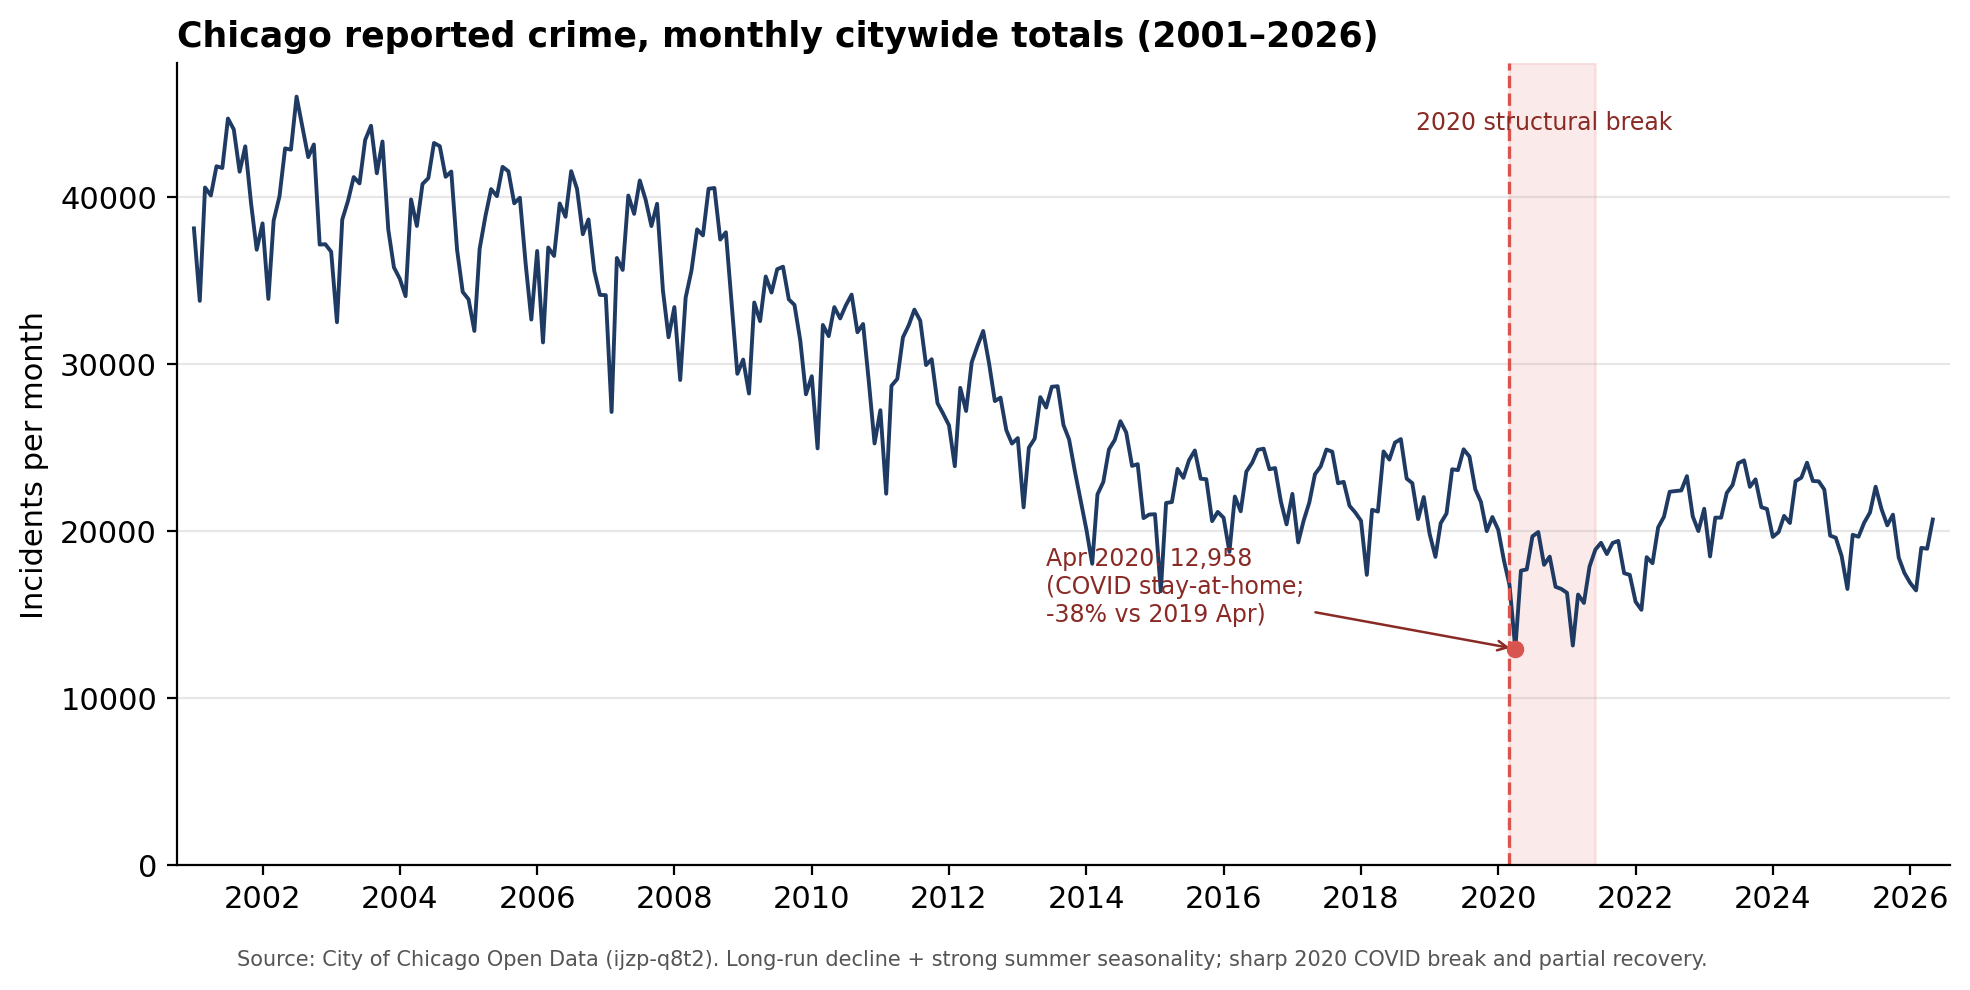

In [2]:
display(Image(filename=str(FIG/'fig1_monthly_overview.png')))

## 2. RQ1 — Base-model accuracy across horizons
XGBoost is the strongest single model; LSTM is competitive at short horizons; all learning models beat the seasonal-naive floor (MASE < 1).

In [3]:
m=pd.read_csv(PROC/'metrics_by_horizon.csv'); test=m[m.split=='test']
for metric in ['RMSE','MASE']:
    print(f'\n{metric} (test 2023+):')
    display(test.pivot(index='name',columns='horizon',values=metric).reindex(ORDER).round(2))


RMSE (test 2023+):


horizon,1,4,8,12
name,,,,
seasonal_naive,35.11,34.58,34.35,34.39
sarima,26.28,27.25,28.35,28.84
prophet,27.26,27.08,27.94,28.96
xgboost,23.15,25.95,27.52,28.66
lstm,23.73,26.20,27.54,30.32
static_inverse_rmse,22.40,23.55,24.36,24.88
horizon_adaptive,22.45,24.00,24.73,26.05
regime_adaptive,22.48,23.70,24.63,25.20



MASE (test 2023+):


horizon,1,4,8,12
name,,,,
seasonal_naive,0.95,0.94,0.93,0.93
sarima,0.71,0.73,0.76,0.78
prophet,0.74,0.75,0.77,0.81
xgboost,0.64,0.70,0.74,0.77
lstm,0.64,0.70,0.74,0.82
static_inverse_rmse,0.61,0.64,0.66,0.67
horizon_adaptive,0.61,0.64,0.66,0.70
regime_adaptive,0.61,0.64,0.66,0.68


## 3. RQ2 — Significance (block-bootstrap, BH-corrected)
**Ensemble vs best single (XGBoost):** robustly significant at **h≥4** (h=1 marginal after correction) — this is the diversification benefit. **Adaptive vs static:** static is *significantly better* than horizon-adaptive at h≥4 in the calm split; regime-adaptive only ties static. Adaptivity does not win.

In [4]:
dm=pd.read_csv(PROC/'dm_tests.csv'); full=dm[dm.window=='full']
cols=['comparison','horizon','DM_stat','p_bootstrap','p_bh','sig_bh_5pct','better']
print('Ensemble vs best single:'); display(full[full.comparison.str.contains('vs xgboost')][cols].round(3))
print('Adaptive vs static blend:'); display(full[full.comparison.str.contains('vs static')][cols].round(3))

Ensemble vs best single:


,comparison,horizon,DM_stat,p_bootstrap,p_bh,sig_bh_5pct,better
0,static_inverse_rmse vs xgboost,1,-2.850,0.013,0.023,True,static_inverse_rmse
1,static_inverse_rmse vs xgboost,4,-6.451,0.000,0.000,True,static_inverse_rmse
2,static_inverse_rmse vs xgboost,8,-4.729,0.000,0.000,True,static_inverse_rmse
3,static_inverse_rmse vs xgboost,12,-3.774,0.000,0.000,True,static_inverse_rmse
4,horizon_adaptive vs xgboost,1,-2.457,0.058,0.077,False,horizon_adaptive
5,horizon_adaptive vs xgboost,4,-4.541,0.000,0.000,True,horizon_adaptive
6,horizon_adaptive vs xgboost,8,-5.651,0.000,0.000,True,horizon_adaptive
7,horizon_adaptive vs xgboost,12,-5.051,0.000,0.000,True,horizon_adaptive
8,regime_adaptive vs xgboost,1,-2.649,0.076,0.095,False,regime_adaptive
9,regime_adaptive vs xgboost,4,-5.278,0.000,0.000,True,regime_adaptive


Adaptive vs static blend:


,comparison,horizon,DM_stat,p_bootstrap,p_bh,sig_bh_5pct,better
12,horizon_adaptive vs static_inverse_rmse,1,0.457,0.452,0.452,False,static_inverse_rmse
13,horizon_adaptive vs static_inverse_rmse,4,1.923,0.025,0.039,True,static_inverse_rmse
14,horizon_adaptive vs static_inverse_rmse,8,1.847,0.018,0.030,True,static_inverse_rmse
15,horizon_adaptive vs static_inverse_rmse,12,2.171,0.002,0.005,True,static_inverse_rmse
16,regime_adaptive vs static_inverse_rmse,1,0.621,0.368,0.387,False,static_inverse_rmse
17,regime_adaptive vs static_inverse_rmse,4,0.817,0.264,0.293,False,static_inverse_rmse
18,regime_adaptive vs static_inverse_rmse,8,1.093,0.185,0.218,False,static_inverse_rmse
19,regime_adaptive vs static_inverse_rmse,12,1.089,0.043,0.062,False,static_inverse_rmse


## 4. The optimal mix shifts with horizon (descriptive)
The weights do change with horizon (LSTM high at short h, ~0 at h=12) — but per §3 this does not yield a significant accuracy gain over the static blend.

In [5]:
w=pd.read_csv(PROC/'ensemble_weights.csv')
display(w[w.scheme=='horizon_adaptive'][['horizon','sarima','prophet','xgboost','lstm']].round(3))

,horizon,sarima,prophet,xgboost,lstm
1,1,0.318,0.080,0.239,0.362
2,4,0.306,0.009,0.218,0.468
3,8,0.235,0.097,0.500,0.167
4,12,0.279,0.066,0.655,0.000


## 5. RQ3 — The 2020 regime break
The regime-adaptive weights re-allocate sharply across the break (Prophet dominates the shock). The adaptive-vs-static edge is **+7–11% (effect size) during the acute shock vs ~0% in calm** — but it is **NOT statistically significant** after robust correction (acute-shock regime-vs-static h=1: p_BH≈0.07). Numerical, regime-contingent edge; not a significant win.

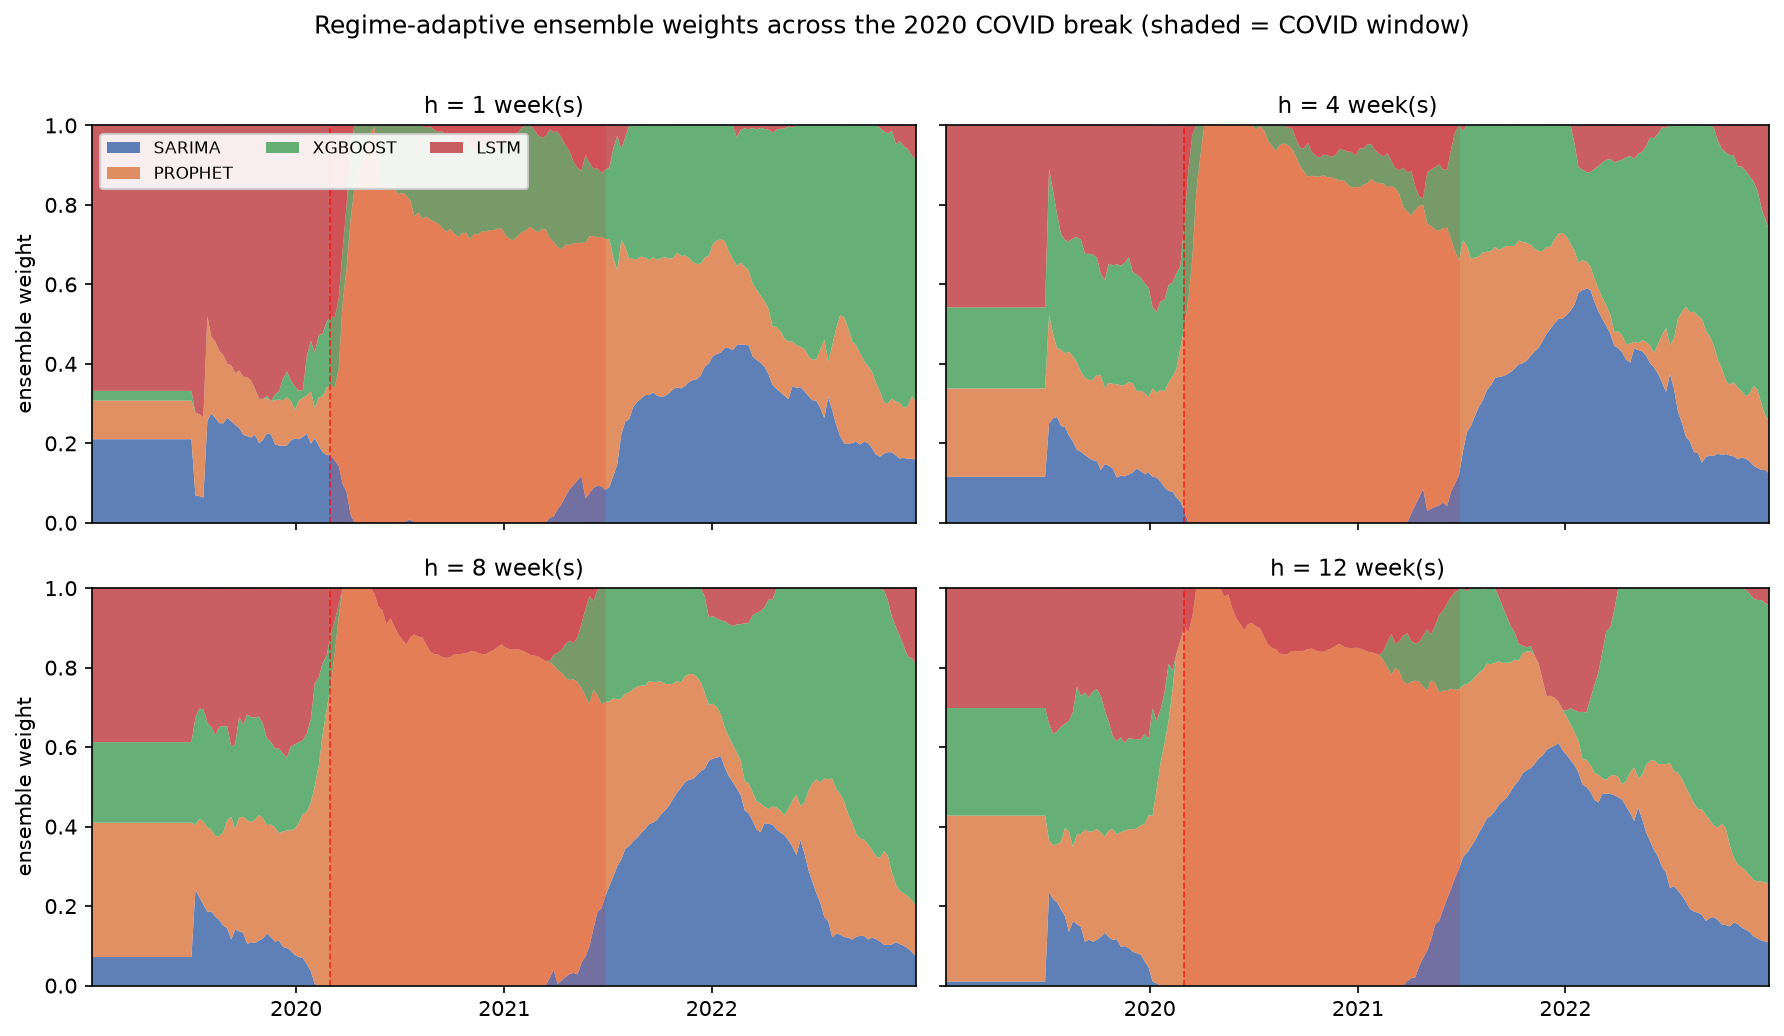

Effect sizes (% RMSE, regime-adaptive vs static):


,window,horizon,rmse_xgb,rmse_static,rmse_regime,regime_vs_static_%
0,pre 2020-01..02,1,21.96,20.31,20.16,0.76
1,pre 2020-01..02,4,45.11,44.14,43.97,0.37
2,pre 2020-01..02,8,81.09,79.97,77.99,2.47
3,pre 2020-01..02,12,98.48,96.19,91.97,4.39
4,shock 2020-03..2021-06,1,34.16,31.33,29.03,7.36
5,shock 2020-03..2021-06,4,40.97,37.77,34.11,9.70
6,shock 2020-03..2021-06,8,42.57,38.28,34.37,10.22
7,shock 2020-03..2021-06,12,41.09,35.67,31.89,10.60
8,recov 2021-07..2022-12,1,28.99,28.46,28.80,-1.21
9,recov 2021-07..2022-12,4,30.63,29.83,30.24,-1.38



Windowed DM — regime_adaptive vs static (reproducible):


,window,horizon,DM_stat,p_bootstrap,p_bh,sig_bh_5pct
36,acute_shock,1,-2.088,0.034,0.070,False
37,acute_shock,4,-1.406,0.040,0.077,False
38,acute_shock,8,-1.218,0.069,0.126,False
39,acute_shock,12,-0.873,0.184,0.269,False
56,recovery,1,0.134,0.832,0.891,False
57,recovery,4,0.229,0.902,0.949,False
58,recovery,8,-0.267,0.738,0.820,False
59,recovery,12,-0.094,0.969,0.969,False


In [6]:
display(Image(filename=str(FIG/'fig_weight_trajectory_2020.png')))
print('Effect sizes (% RMSE, regime-adaptive vs static):')
display(pd.read_csv(PROC/'robustness_regimes.csv').round(2))
rdm=pd.read_csv(PROC/'regime2020'/'dm_tests.csv')
print('\nWindowed DM — regime_adaptive vs static (reproducible):')
display(rdm[(rdm.comparison=='regime_adaptive vs static_inverse_rmse') & (rdm.window!='full')][['window','horizon','DM_stat','p_bootstrap','p_bh','sig_bh_5pct']].round(3))

## 6. H4 — Per-district heterogeneity (honest negative)
Ensemble helps in most districts but the gain does **not** scale with district volatility (Spearman ρ≈0.17, n.s.).

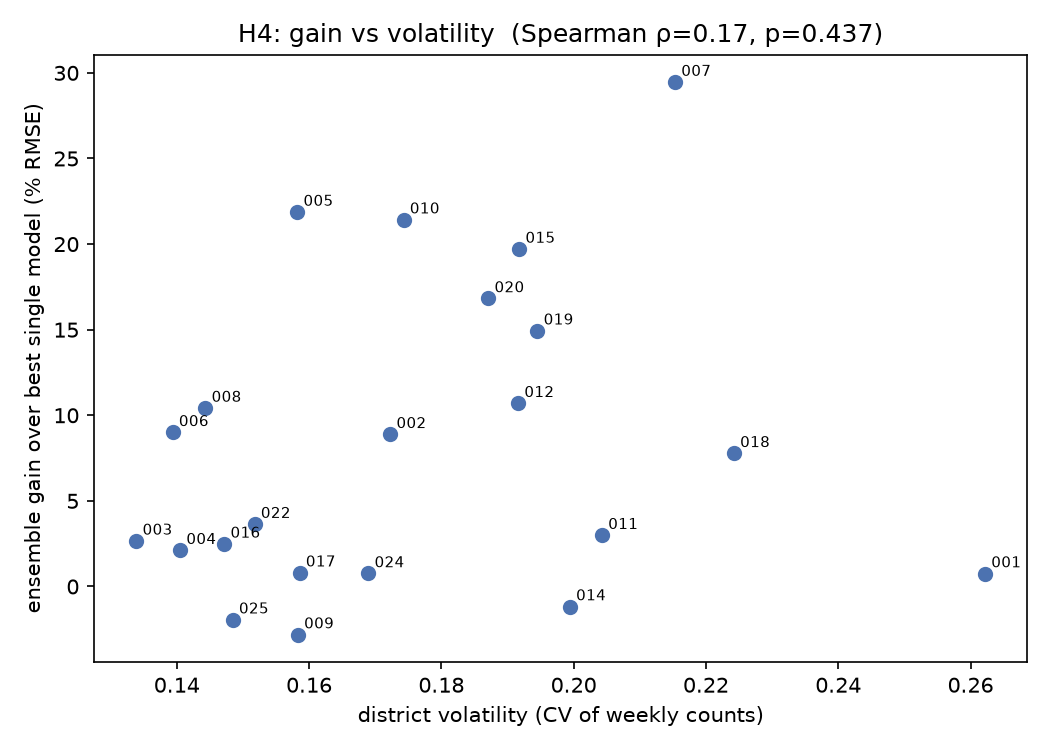

mean gain %: 8.2 | helped 19 of 22 districts


In [7]:
display(Image(filename=str(FIG/'fig_h4_gain_vs_volatility.png')))
bd=pd.read_csv(PROC/'robustness_by_district.csv')
print('mean gain %:',round(bd.gain_pct.mean(),1),'| helped',int((bd.gain_pct>0).sum()),'of',len(bd),'districts')

## 7. Robustness — seeds & training-window length
Stable across seeds (ensembling reduces variance) and robust to training-window start.

In [8]:
sd=pd.read_csv(PROC/'robustness_seeds.csv')
display(sd.groupby('horizon')[['xgb_rmse','ens_rmse']].agg(['mean','std']).round(3))
display(pd.read_csv(PROC/'robustness_trainwindow.csv').pivot(index='train_start',columns='horizon',values='ens_rmse').round(2))

xgb_rmse        ens_rmse       
            mean    std     mean    std
horizon                                
1         23.216  0.110   22.466  0.020
4         26.027  0.163   24.032  0.027
8         27.477  0.176   24.670  0.093
12        28.732  0.241   26.067  0.124

horizon,1,4,8,12
train_start,,,,
2015-01-01,22.45,24.00,24.73,26.05
2017-01-01,22.56,24.11,24.79,26.29
2019-01-01,22.54,24.20,24.87,26.51


## 8. Interpretability — SHAP on the XGBoost member
Drivers shift with horizon: recent rolling means (momentum) at short horizons; month/week-of-year (seasonality) at long horizons.

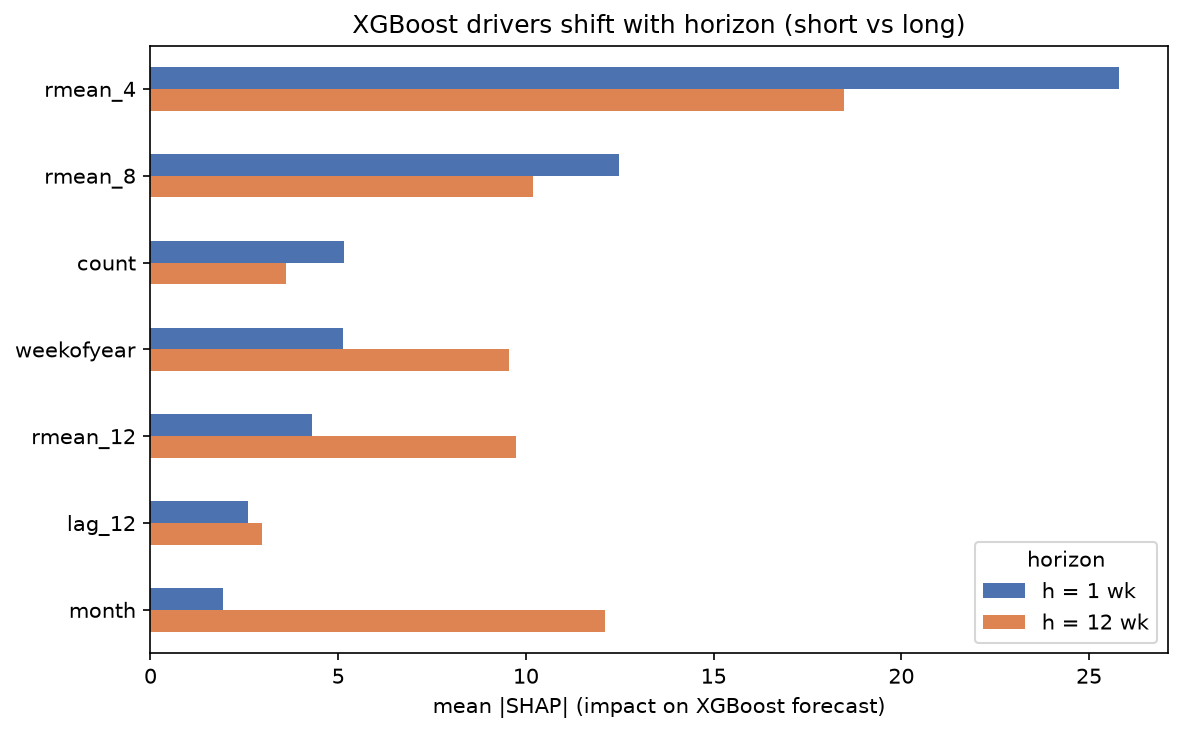

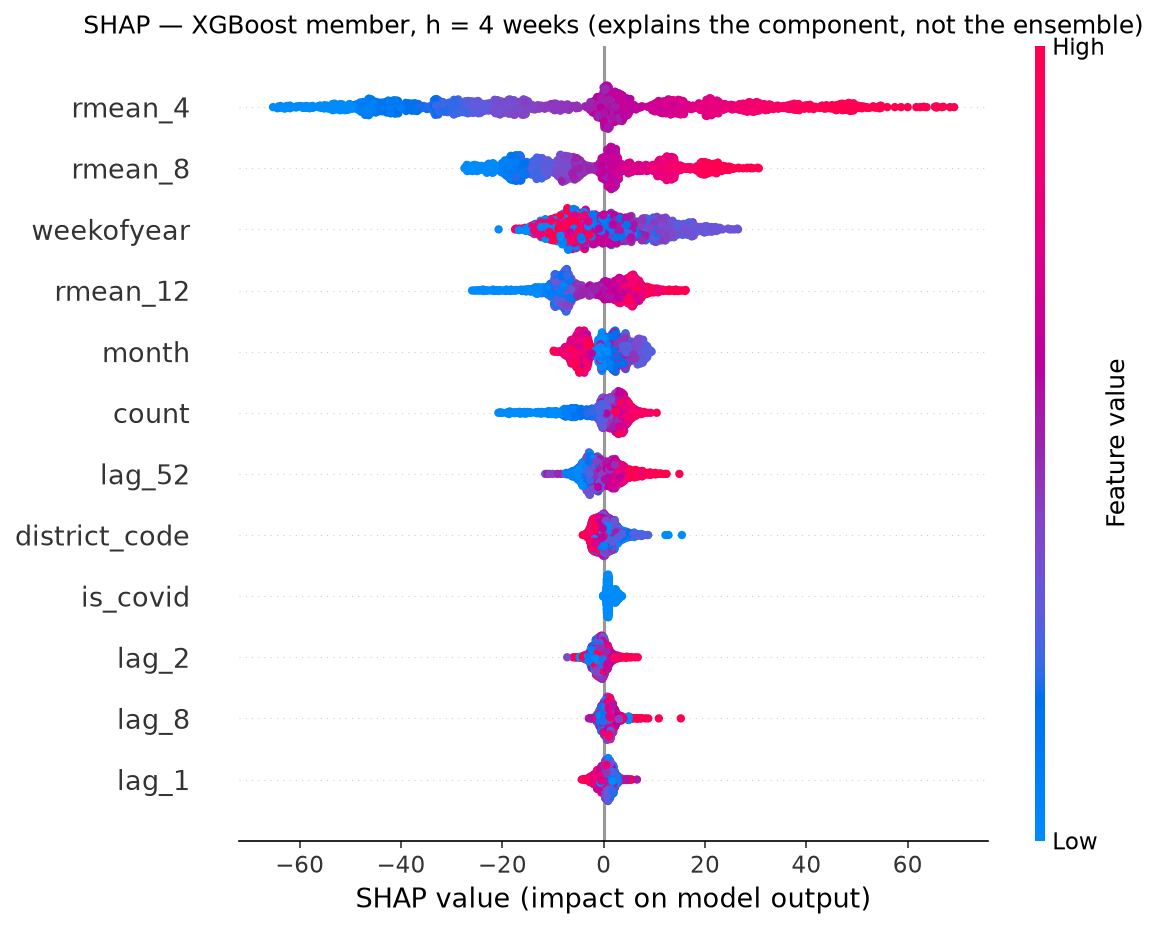

h= 1: rmean_4=25.8, rmean_8=12.5, count=5.2, weekofyear=5.1, rmean_12=4.3
h= 4: rmean_4=24.4, rmean_8=11.4, weekofyear=7.5, rmean_12=6.6, month=3.9
h= 8: rmean_4=17.1, rmean_8=15.4, rmean_12=9.7, weekofyear=9.5, month=7.8
h=12: rmean_4=18.5, month=12.1, rmean_8=10.2, rmean_12=9.7, weekofyear=9.6


In [9]:
display(Image(filename=str(FIG/'fig_shap_by_horizon.png')))
display(Image(filename=str(FIG/'fig_shap_summary.png')))
si=pd.read_csv(PROC/'shap_importance.csv')
for h in [1,4,8,12]:
    top=si[si.horizon==h].nlargest(5,'mean_abs_shap')
    print(f'h={h:>2}:', ', '.join(f'{r.feature}={r.mean_abs_shap:.1f}' for r in top.itertuples()))

## 9. Hypothesis scorecard (honest, post-correction)
| | Hypothesis | Outcome |
|---|---|---|
| H1 | ensemble advantage grows with horizon | **Supported at h≥4** (robust); h=1 marginal |
| H2 | optimal weights not constant across horizons | **Supported descriptively** (no accuracy gain) |
| H3 | regime/adaptive > static across 2020 | **Not significant** (numerical +7–11% in shock, p_BH≈0.07) |
| H4 | gains larger in higher-volatility districts | **Not supported** (ρ≈0.17, n.s.) |
| H5 | adaptive beats seasonal-naive at all horizons | **Supported** (MASE < 1) |

**Defensible contribution:** simple static combination is robust and hard to beat (forecast-combination puzzle); adaptive weighting offers a numerical, non-significant regime-contingent edge; the value of combination is diversification.